<a href="https://colab.research.google.com/github/GeorgeT27/Generative-model-DYI/blob/main/Conditional_Flow_Matching_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn.functional as F
import torch.nn as nn
import math
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor, Compose, Normalize
from torch.utils.data import DataLoader
from torch.optim import Adam, AdamW
from torch.optim.lr_scheduler import StepLR
import torch.distributions as distributions
from tqdm import tqdm
import pandas as pd
from copy import deepcopy
from morphomnist import io
import os 

# Create Morpho Dataset class

In [2]:
class MorphoMNISTDataset(torch.utils.data.Dataset):
    """Custom dataset class for Morpho-MNIST data"""

    def __init__(self, root, train=True, download=False, transform=None,
                 load_morphometrics=False, load_perturbations=False, variant='global'):
        self.root = root
        self.train = train
        self.transform = transform
        self.load_morphometrics = load_morphometrics
        self.load_perturbations = load_perturbations
        self.variant = variant

        # Updated path structure to match your data organization
        self.morpho_dir = os.path.join(root, f'Morpho_MNIST/{variant}')
        if not os.path.exists(self.morpho_dir):
            os.makedirs(self.morpho_dir)
            print(f"Created directory: {self.morpho_dir}")

        if download:
            self.download_data()

        # Load data
        try:
            self.data, self.targets, self.morphometrics, self.perturbations = self._load_data()
            print(f"✅ Successfully loaded {len(self.data)} samples from {self.morpho_dir}")
        except FileNotFoundError as e:
            print(f"❌ Data files not found: {e}")
            print("Please download the data manually (see instructions above)")
            raise

    def download_data(self):
        """Download Morpho-MNIST data if not exists"""
        print("📥 Manual download required:")
        print("1. Go to: https://drive.google.com/drive/folders/1ZzTBfXUKa4JW0lHkUIJ1qFCCSkOqWFvL")
        print(f"2. Download: {self.variant}.tar.gz")
        print(f"3. Extract to: {self.morpho_dir}")
        print("\nAvailable variants: plain, global, local, thin, thic, swel, frac")

    def _load_data(self):
        """Load Morpho-MNIST data files"""
        prefix = 'train' if self.train else 't10k'

        # Load images
        images_file = os.path.join(self.morpho_dir, f'{prefix}-images-idx3-ubyte.gz')
        if os.path.exists(images_file):
            print(f"Loading images from: {images_file}")
            images = io.load_idx(images_file)
        else:
            raise FileNotFoundError(f"Images file not found: {images_file}")

        # Load labels
        labels_file = os.path.join(self.morpho_dir, f'{prefix}-labels-idx1-ubyte.gz')
        if os.path.exists(labels_file):
            print(f"Loading labels from: {labels_file}")
            labels = io.load_idx(labels_file)
        else:
            raise FileNotFoundError(f"Labels file not found: {labels_file}")

        # Load morphometrics (CSV file) - only if requested
        morphometrics = None
        if self.load_morphometrics:
            morpho_file = os.path.join(self.morpho_dir, f'{prefix}-morpho.csv')
            if os.path.exists(morpho_file):
                print(f"Loading morphometrics from: {morpho_file}")
                morphometrics = pd.read_csv(morpho_file)
                print(f"Morphometric features: {list(morphometrics.columns)}")
            else:
                print(f"Warning: Morphometrics file not found: {morpho_file}")

        # Load perturbation labels (if available) - only if requested
        perturbations = None
        if self.load_perturbations:
            pert_file = os.path.join(self.morpho_dir, f'{prefix}-pert-idx1-ubyte.gz')
            if os.path.exists(pert_file):
                print(f"Loading perturbations from: {pert_file}")
                perturbations = io.load_idx(pert_file)
            else:
                print(f"Warning: Perturbation file not found: {pert_file}")

        return images, labels, morphometrics, perturbations

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image = self.data[idx]
        target = self.targets[idx]

        # Convert to tensor and normalize to [0, 1]
        image = torch.from_numpy(image.copy()).float() / 255.0
        image = image.unsqueeze(0)  # Add channel dimension

        if self.transform:
            image = self.transform(image)

        sample = {
            'image': image,
            'target': target,
        }

        if self.morphometrics is not None:
            morpho_data = self.morphometrics.iloc[idx]
            sample['morphometrics'] = {
                'area': morpho_data['area'],
                'length': morpho_data['length'], 
                'thickness': morpho_data['thickness'],
                'slant': morpho_data['slant'],
                'width': morpho_data['width'],
                'height': morpho_data['height']
            }

        if self.perturbations is not None:
            sample['perturbation'] = self.perturbations[idx]

        return sample

In [3]:
# Option 1: Basic usage (no morphometrics/perturbations) - Most memory efficient
dataset = MorphoMNISTDataset(
    root='/workspace/Generative-model-DYI/data',
    train=True,
    download=False,  # Will show download instructions
    transform=None,  # We handle normalization in the custom dataset
    load_morphometrics=True,  # Don't load morphometrics to save memory
    load_perturbations=True   # Don't load perturbations to save memory
)


def morpho_collate_fn(batch):
    images = torch.stack([item['image'] for item in batch])
    targets = torch.tensor([item['target'] for item in batch], dtype=torch.long)  # Fix: ensure LongTensor

    # Extract morphometric features into tensors
    morphometrics = None
    if any('morphometrics' in item for item in batch):
        morpho_data = [item.get('morphometrics', None) for item in batch]
        if morpho_data[0] is not None:  # Check if morphometrics are actually loaded
            morphometrics = {
                'thickness': torch.tensor([m['thickness'] for m in morpho_data], dtype=torch.float32)
            }

    return images, targets, morphometrics

Loading images from: /workspace/Generative-model-DYI/data/Morpho_MNIST/global/train-images-idx3-ubyte.gz
Loading labels from: /workspace/Generative-model-DYI/data/Morpho_MNIST/global/train-labels-idx1-ubyte.gz
Loading morphometrics from: /workspace/Generative-model-DYI/data/Morpho_MNIST/global/train-morpho.csv
Morphometric features: ['index', 'area', 'length', 'thickness', 'slant', 'width', 'height']
Loading perturbations from: /workspace/Generative-model-DYI/data/Morpho_MNIST/global/train-pert-idx1-ubyte.gz
✅ Successfully loaded 60000 samples from /workspace/Generative-model-DYI/data/Morpho_MNIST/global


In [4]:
class RectifiedFlow:
  def euler(self,x_t,v,dt):
    x_t=x_t+v*dt
    return x_t
  def create_flow(self,x_1,t):
    x_0=torch.randn_like(x_1)
    t=t[:,None,None,None]
    x_t=t*x_1+(1-t)*x_0
    return x_t,x_0
  def mse_loss(self,x_1,x_0,v):
    loss=F.mse_loss(x_1-x_0,v)
    return loss

In [17]:
# Deeper UNet for MNIST 28*28 with thickness conditioning
class DownLayer(nn.Module):
    """MiniUnet的下采样层 Resnet
    """

    def __init__(self,
                 in_channels,
                 out_channels,
                 time_emb_dim=16,
                 downsample=False):
        super(DownLayer, self).__init__()

        self.conv1 = nn.Conv2d(in_channels,
                               out_channels,
                               kernel_size=3,
                               padding=1)
        self.conv2 = nn.Conv2d(out_channels,
                               out_channels,
                               kernel_size=3,
                               padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.act = nn.ReLU()

        # 线性层，用于时间编码换通道 [B, dim] -> [B, in_channels]
        self.fc = nn.Linear(time_emb_dim, in_channels)

        if in_channels != out_channels:
            self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        else:
            self.shortcut = None

        # 降采样
        self.downsample = downsample
        if downsample:
            self.pool = nn.MaxPool2d(2)

        self.in_channels = in_channels

    def forward(self, x, temb):
        # x: [B, C, H, W]
        res = x
        x += self.fc(temb)[:, :, None, None]  # [B, in_channels, 1, 1]
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.act(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.act(x)

        if self.shortcut is not None:
            res = self.shortcut(res)

        x = x + res

        if self.downsample:
            x = self.pool(x)

        return x


class UpLayer(nn.Module):
    """MiniUnet的上采样层
    """

    def __init__(self,
                 in_channels,
                 out_channels,
                 time_emb_dim=16,
                 upsample=False):
        super(UpLayer, self).__init__()

        self.conv1 = nn.Conv2d(in_channels,
                               out_channels,
                               kernel_size=3,
                               padding=1)
        self.conv2 = nn.Conv2d(out_channels,
                               out_channels,
                               kernel_size=3,
                               padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.act = nn.ReLU()

        # 线性层，用于时间编码换通道
        self.fc = nn.Linear(time_emb_dim, in_channels)

        if in_channels != out_channels:
            self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        else:
            self.shortcut = None

        self.upsample = upsample
        if upsample:
            self.upsample = nn.Upsample(scale_factor=2)

    def forward(self, x, temb):
        # 上采样
        if self.upsample:
            x = self.upsample(x)
        res = x

        x += self.fc(temb)[:, :, None, None]
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.act(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.act(x)

        if self.shortcut is not None:
            res = self.shortcut(res)
        x = x + res

        return x


class MiddleLayer(nn.Module):
    """MiniUnet的中间层
    """

    def __init__(self, in_channels, out_channels, time_emb_dim=16):
        super(MiddleLayer, self).__init__()

        self.conv1 = nn.Conv2d(in_channels,
                               out_channels,
                               kernel_size=3,
                               padding=1)
        self.conv2 = nn.Conv2d(out_channels,
                               out_channels,
                               kernel_size=3,
                               padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.act = nn.ReLU()

        # 线性层，用于时间编码换通道
        self.fc = nn.Linear(time_emb_dim, in_channels)

        if in_channels != out_channels:
            self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        else:
            self.shortcut = None

    def forward(self, x, temb):
        res = x

        x += self.fc(temb)[:, :, None, None]
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.act(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.act(x)

        if self.shortcut is not None:
            x = self.shortcut(x)
        x = x + res

        return x


class DeeperUnet(nn.Module):
    """Fixed Deeper UNet for MNIST with thickness conditioning
    """

    def __init__(self, base_channels=32, time_emb_dim=None):
        super(DeeperUnet, self).__init__()

        if time_emb_dim is None:
            time_emb_dim = base_channels

        self.time_emb_dim = time_emb_dim
        self.base_channels = base_channels

        self.conv_in = nn.Conv2d(1, base_channels, kernel_size=3, padding=1)

        # Down blocks - Fixed architecture
        # Level 1: 28x28 -> 14x14
        self.down1 = nn.ModuleList([
            DownLayer(base_channels,
                      base_channels * 2,
                      time_emb_dim=time_emb_dim,
                      downsample=False),
            DownLayer(base_channels * 2,
                      base_channels * 2,
                      time_emb_dim=time_emb_dim)
        ])
        self.maxpool1 = nn.MaxPool2d(2)  # 28x28 -> 14x14

        # Level 2: 14x14 -> 7x7
        self.down2 = nn.ModuleList([
            DownLayer(base_channels * 2,
                      base_channels * 4,
                      time_emb_dim=time_emb_dim,
                      downsample=False),
            DownLayer(base_channels * 4,
                      base_channels * 4,
                      time_emb_dim=time_emb_dim)
        ])
        self.maxpool2 = nn.MaxPool2d(2)  # 14x14 -> 7x7

        # Level 3: 7x7 -> 3x3 (using stride 2 for odd dimensions)
        self.down3 = nn.ModuleList([
            DownLayer(base_channels * 4,
                      base_channels * 8,
                      time_emb_dim=time_emb_dim,
                      downsample=False),
            DownLayer(base_channels * 8,
                      base_channels * 8,
                      time_emb_dim=time_emb_dim)
        ])
        # Use conv with stride 2 - 7x7 -> 3x3 (more natural for odd dimensions)
        self.maxpool3 = nn.Conv2d(base_channels * 8, base_channels * 8, 
                                  kernel_size=3, stride=2, padding=0)  # 7x7 -> 3x3

        # Middle layer
        self.middle = MiddleLayer(base_channels * 8,
                                  base_channels * 8,
                                  time_emb_dim=time_emb_dim)

        # Up blocks - Fixed with proper dimensions
        # Level 1: 3x3 -> 7x7 (to match x3)
        self.upsample1 = nn.ConvTranspose2d(base_channels * 8, base_channels * 8, 
                                           kernel_size=3, stride=2, padding=0, output_padding=0)  # 3x3 -> 7x7
        
        self.up1 = nn.ModuleList([
            UpLayer(
                base_channels * 16,  # concat from down3: 8*base + 8*base
                base_channels * 4,
                time_emb_dim=time_emb_dim,
                upsample=False),
            UpLayer(base_channels * 4,
                    base_channels * 4,
                    time_emb_dim=time_emb_dim)
        ])
        
        # Level 2: 7x7 -> 14x14 (to match x2)
        self.upsample2 = nn.ConvTranspose2d(base_channels * 4, base_channels * 4, 
                                           kernel_size=2, stride=2)  # 7x7 -> 14x14
        self.up2 = nn.ModuleList([
            UpLayer(base_channels * 8,  # concat from down2: 4*base + 4*base
                    base_channels * 2,
                    time_emb_dim=time_emb_dim,
                    upsample=False),
            UpLayer(base_channels * 2,
                    base_channels * 2,
                    time_emb_dim=time_emb_dim)
        ])
        
        # Level 3: 14x14 -> 28x28 (to match x1)
        self.upsample3 = nn.ConvTranspose2d(base_channels * 2, base_channels * 2, 
                                           kernel_size=2, stride=2)  # 14x14 -> 28x28
        self.up3 = nn.ModuleList([
            UpLayer(base_channels * 4,  # concat from down1: 2*base + 2*base
                    base_channels,
                    time_emb_dim=time_emb_dim,
                    upsample=False),
            UpLayer(base_channels,
                    base_channels,
                    time_emb_dim=time_emb_dim)
        ])

        self.conv_out = nn.Conv2d(base_channels, 1, kernel_size=1, padding=0)

    def time_emb(self, t, dim):
        """对时间进行正弦函数的编码"""
        # 把t映射到[0, 1000]
        t = t * 1000
        freqs = torch.pow(10000, torch.linspace(0, 1, dim // 2)).to(t.device)
        sin_emb = torch.sin(t[:, None] / freqs)
        cos_emb = torch.cos(t[:, None] / freqs)

        return torch.cat([sin_emb, cos_emb], dim=-1)

    def label_emb(self, y, dim):
        """对类别标签进行编码"""
        y = y * 1000
        freqs = torch.pow(10000, torch.linspace(0, 1, dim // 2)).to(y.device)
        sin_emb = torch.sin(y[:, None] / freqs)
        cos_emb = torch.cos(y[:, None] / freqs)

        return torch.cat([sin_emb, cos_emb], dim=-1)

    def thickness_emb(self, thickness, dim):
        """对thickness进行编码 - Fixed normalization"""
        # Normalize thickness to reasonable range first
        thickness_norm = torch.clamp(thickness, 0.1, 5.0)  # Clamp to reasonable range
        thickness_scaled = thickness_norm * 200  # Reduce scaling factor
    
        freqs = torch.pow(10000, torch.linspace(0, 1, dim // 2)).to(thickness.device)
        sin_emb = torch.sin(thickness_scaled[:, None] / freqs)
        cos_emb = torch.cos(thickness_scaled[:, None] / freqs)
    
        return torch.cat([sin_emb, cos_emb], dim=-1)

    def forward(self, x, t, y=None, thickness=None):
        """前向传播函数 - Fixed embedding handling"""
        # x:(B, C, H, W) - Input should be 28x28
        x = self.conv_in(x)  # 28x28 -> 28x28 with base_channels
        
        # Create separate embeddings and concatenate them
        temb = self.time_emb(t, self.base_channels)
        
        # Handle label conditioning
        if y is not None:
            yemb = self.label_emb(y, self.base_channels)
            yemb[y == -1] = 0.0
            temb = temb + yemb  # Add instead of concatenate to maintain dimension
        
        # Handle thickness conditioning
        if thickness is not None:
            thickness_emb = self.thickness_emb(thickness, self.base_channels)
            thickness_emb[thickness == -1] = 0.0
            temb = temb + thickness_emb  # Add instead of concatenate
        
        # Down path with skip connections
        for layer in self.down1:
            x = layer(x, temb)
        x1 = x  # Skip connection 1: [B, 64, 28, 28]
        x = self.maxpool1(x)  # [B, 64, 14, 14]
        
        for layer in self.down2:
            x = layer(x, temb)
        x2 = x  # Skip connection 2: [B, 128, 14, 14]
        x = self.maxpool2(x)  # [B, 128, 7, 7]
        
        for layer in self.down3:
            x = layer(x, temb)
        x3 = x  # Skip connection 3: [B, 256, 7, 7]
        x = self.maxpool3(x)  # [B, 256, 3, 3]

        # Middle layer
        x = self.middle(x, temb)  # [B, 256, 3, 3]

        # Up path with skip connections
        x = self.upsample1(x)  # [B, 256, 7, 7] - Now matches x3 exactly
        x = torch.cat([x, x3], dim=1)  # [B, 512, 7, 7]
        for layer in self.up1:
            x = layer(x, temb)  # [B, 128, 7, 7]
            
        x = self.upsample2(x)  # [B, 128, 14, 14]
        x = torch.cat([x, x2], dim=1)  # [B, 256, 14, 14]
        for layer in self.up2:
            x = layer(x, temb)  # [B, 64, 14, 14]
            
        x = self.upsample3(x)  # [B, 64, 28, 28]
        x = torch.cat([x, x1], dim=1)  # [B, 128, 28, 28]
        for layer in self.up3:
            x = layer(x, temb)  # [B, 32, 28, 28]

        x = self.conv_out(x)  # [B, 1, 28, 28]
        return x

In [13]:
# Test the fixed model architecture
print("Testing fixed model architecture...")
test_model = DeeperUnet(base_channels=32)

# Create test inputs
batch_size = 2
x_test = torch.randn(batch_size, 1, 28, 28)
t_test = torch.rand(batch_size)
y_test = torch.randint(0, 10, (batch_size,))
thickness_test = torch.rand(batch_size) * 2.0 + 0.5  # Random thickness values

print(f"Input shapes:")
print(f"  x: {x_test.shape}")
print(f"  t: {t_test.shape}")
print(f"  y: {y_test.shape}")
print(f"  thickness: {thickness_test.shape}")

# Test forward pass
try:
    output = test_model(x_test, t_test, y_test, thickness_test)
    print(f"✅ Success! Output shape: {output.shape}")
    print("Model architecture is working correctly!")
except Exception as e:
    print(f"❌ Error: {e}")

Testing fixed model architecture...
Input shapes:
  x: torch.Size([2, 1, 28, 28])
  t: torch.Size([2])
  y: torch.Size([2])
  thickness: torch.Size([2])
✅ Success! Output shape: torch.Size([2, 1, 28, 28])
Model architecture is working correctly!


In [18]:
class EMA(nn.Module):
    def __init__(self, model, decay=0.9999, device=None):
        super(EMA, self).__init__()
        # make a copy of the model for accumulating moving average of weights
        self.module = deepcopy(model)
        self.module.eval()
        self.decay = decay
        self.device = device  # perform EMA on different device from model if set
        if self.device is not None:
            self.module.to(device=self.device)

    def _update(self, model, update_fn):
        with torch.no_grad():
            for ema_v, model_v in zip(self.module.state_dict().values(),
                                      model.state_dict().values()):
                if self.device is not None:
                    model_v = model_v.to(device=self.device)
                ema_v.copy_(update_fn(ema_v, model_v))

    def update(self, model):
        self._update(
            model,
            update_fn=lambda e, m: self.decay * e + (1.0 - self.decay) * m
        )

    def set(self, model):
        self._update(
            model,
            update_fn=lambda e, m: m
        )

In [19]:
# Improved training configuration
epochs= 100  # More epochs
batch_size= 128  # Larger batch size for more stable gradients
lr= 5e-4  # Slightly higher learning rate initially
weight_decay= 1e-4  # Less regularization
ema_decay= 0.9999
grad_clip= 1.0
lr_schedule= True
step_size= 40  # Reduce LR later
gamma= 0.5 # More gradual LR reduction
lr_adjust_epoch= 25 # 学习率调整的epoch，降为原有的10%
batch_print_interval= 100 # 打印间隔，以batch为单位
device= 'cuda' # cuda、cpu、mps(only macbook)
checkpoint_save_interval= 10 # 模型保存间隔，以epoch为单位

In [22]:
import pandas as pd  # Add this import for morpho dataset

# Use MorphoMNIST dataset instead of regular MNIST
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, collate_fn=morpho_collate_fn)

# IMPORTANT: Recreate the model with fixed architecture
print("Creating new model with fixed architecture...")
model = DeeperUnet(base_channels=32).to(device)  # Use fixed deeper model
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
schedular = StepLR(optimizer, step_size=step_size, gamma=gamma)
rf = RectifiedFlow()
ema = EMA(model, decay=0.999, device=device)

print("Starting training with thickness conditioning...")
for epoch in range(epochs):
    pbar = tqdm(dataloader, desc=f'Epoch {epoch}')
    total_loss = 0
    num_batches = 0
    
    for batch_data in pbar:
        images, labels, morphometrics = batch_data
        x_1 = images
        y = labels
        
        # Extract thickness if available
        thickness = None
        if morphometrics is not None and 'thickness' in morphometrics:
            thickness = morphometrics['thickness']
            # Debug: Check thickness values
            if epoch == 0 and num_batches == 0:
                print(f"Thickness range: {thickness.min():.3f} to {thickness.max():.3f}")
        
        t = torch.rand(x_1.size(0))
        x_t, x_0 = rf.create_flow(x_1, t)
        x_t = x_t.to(device)
        x_0 = x_0.to(device)
        x_1 = x_1.to(device)
        t = t.to(device)
        y = y.to(device)
        
        if thickness is not None:
            thickness = thickness.to(device)
        
        optimizer.zero_grad()
        
        # We train with both conditional and unconditional model
        x_t = torch.cat([x_t, x_t.clone()], dim=0)
        x_0 = torch.cat([x_0, x_0.clone()], dim=0)
        x_1 = torch.cat([x_1, x_1.clone()], dim=0)
        t = torch.cat([t, t.clone()], dim=0)
        y = torch.cat([y, -torch.ones_like(y)], dim=0)
        
        # Handle thickness conditioning
        if thickness is not None:
            thickness = torch.cat([thickness, -torch.ones_like(thickness)], dim=0)  # -1 for unconditional
        
        # Debug: Check tensor shapes before model forward
        if epoch == 0 and num_batches == 0:
            print(f"Input shapes: x_t={x_t.shape}, t={t.shape}, y={y.shape}")
            if thickness is not None:
                print(f"Thickness shape: {thickness.shape}")
        
        v_pred = model(x_t, t, y, thickness)
        loss = rf.mse_loss(x_1, x_0, v_pred)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        ema.update(model)
        
        total_loss += loss.item()
        num_batches += 1
        
        # Update progress bar
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'avg_loss': f'{total_loss/num_batches:.4f}'})
        
    if epoch % 5 == 0:
        print(f"Epoch {epoch}: Average loss = {total_loss/num_batches:.4f}")
        torch.save({
            'model_state_dict': model.state_dict(),
            'ema_state_dict': ema.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'epoch': epoch,
            'loss': total_loss/num_batches
        }, f"morpho_ckpt_{epoch}.pth")
        print(f"Checkpoint saved: morpho_ckpt_{epoch}.pth")

print("Training completed!")

Creating new model with fixed architecture...
Model parameters: 6,713,409
Starting training with thickness conditioning...


Epoch 0:   0%|          | 0/469 [00:00<?, ?it/s]

Thickness range: 0.963 to 8.153
Input shapes: x_t=torch.Size([256, 1, 28, 28]), t=torch.Size([256]), y=torch.Size([256])
Thickness shape: torch.Size([256])


Epoch 0: 100%|██████████| 469/469 [01:09<00:00,  6.75it/s, loss=0.0956, avg_loss=0.1539]



Epoch 0: Average loss = 0.1539
Checkpoint saved: morpho_ckpt_0.pth


...

Epoch 15: Average loss = 0.0770
Checkpoint saved: morpho_ckpt_15.pth


Epoch 20: 100%|██████████| 469/469 [01:06<00:00,  7.06it/s, loss=0.0751, avg_loss=0.0756]



Epoch 20: Average loss = 0.0756
Checkpoint saved: morpho_ckpt_20.pth


Epoch 21:   6%|▋         | 30/469 [00:04<01:02,  7.01it/s, loss=0.0778, avg_loss=0.0755]



KeyboardInterrupt: 

Using the EMA model for high-quality sample generation...
Generating 9 samples using EMA model...
Using 100 integration steps for high quality...
Label conditioning: tensor([1, 2, 3, 4, 5, 6, 7, 8, 9])
Thickness conditioning: tensor([2.0000, 2.2500, 2.5000, 2.7500, 3.0000, 3.2500, 3.5000, 3.7500, 4.0000])
Visualizing samples...
Visualizing samples...


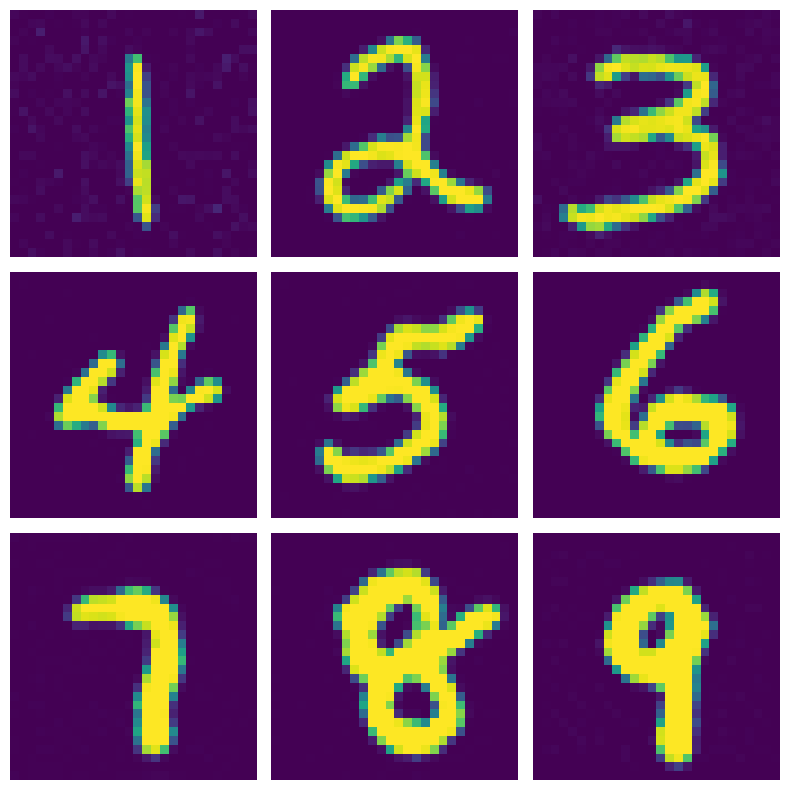

In [45]:
import numpy as np
import matplotlib.pyplot as plt

def sample(model, rf, num_samples, cfg_scale, y=None, thickness=None, num_steps=50, device='cuda'):
    """Generate samples using the trained flow matching model with thickness conditioning

    Args:
        model: Trained DeeperUnet model
        rf: RectifiedFlow instance
        num_samples: Number of samples to generate
        cfg_scale: Classifier-free guidance scale
        y: Label conditioning (optional)
        thickness: Thickness conditioning (optional)
        num_steps: Number of integration steps
        device: Device to run on
    """
    if y is not None:
        assert len(y.shape) == 1, 'y must be 1D tensor'
        if y.shape[0] == 1:
            y = y.repeat(num_samples).reshape(num_samples)
        y = y.to(device)
    
    if thickness is not None:
        assert len(thickness.shape) == 1, 'thickness must be 1D tensor'
        if thickness.shape[0] == 1:
            thickness = thickness.repeat(num_samples).reshape(num_samples)
        thickness = thickness.to(device)
    
    model.eval()
    with torch.no_grad():
        dt = 1.0 / num_steps
        # Start from noise
        x_t = torch.randn(num_samples, 1, 28, 28, device=device)

        # Integrate the flow from t=0 to t=1
        for i in range(num_steps):
            t = torch.full((num_samples,), i * dt, device=device)
            v_pred_uncon = model(x_t, t)  # Unconditional
            v_pred_con = model(x_t, t, y, thickness)  # Conditional with both y and thickness
            v_pred = v_pred_uncon + cfg_scale * (v_pred_con - v_pred_uncon)
            x_t = rf.euler(x_t, v_pred, dt)

        return x_t

def visualize_samples(samples, num_display=16, figsize=(8, 8), colormap='viridis'):
    """Visualize generated samples with color

    Args:
        samples: Generated samples tensor [B, 1, 28, 28]
        num_display: Number of samples to display
        figsize: Figure size
        colormap: Matplotlib colormap for coloring ('viridis', 'plasma', 'inferno', 'magma', 'jet', 'rainbow', etc.)
    """
    # Move to CPU and convert to numpy
    samples = samples.cpu().numpy()

    # Clamp values to [0, 1] range
    samples = np.clip(samples, 0, 1)

    # Calculate grid dimensions
    grid_size = int(np.sqrt(num_display))
    if grid_size * grid_size < num_display:
        grid_size += 1

    fig, axes = plt.subplots(grid_size, grid_size, figsize=figsize)
    axes = axes.flatten() if num_display > 1 else [axes]

    for i in range(num_display):
        if i < len(samples):
            # Remove channel dimension and display with color
            img = samples[i, 0]  # Shape: [28, 28]
            axes[i].imshow(img, cmap=colormap)  # Use specified colormap instead of 'gray'
            axes[i].axis('off')
        else:
            axes[i].axis('off')

    plt.tight_layout()
    plt.show()

def generate_samples_with_ema(ema_model, rf, cfg_scale, y=None, thickness=None, num_samples=16, num_steps=100, device='cuda'):
    """Generate samples using the EMA model with thickness conditioning

    Args:
        ema_model: The EMA model (ema.module)
        rf: RectifiedFlow instance
        cfg_scale: Classifier-free guidance scale
        y: Label conditioning (optional)
        thickness: Thickness conditioning (optional)
        num_samples: Number of samples to generate
        num_steps: Number of integration steps for better quality
    """
    print(f"Generating {num_samples} samples using EMA model...")
    print(f"Using {num_steps} integration steps for high quality...")
    if y is not None:
        print(f"Label conditioning: {y}")
    if thickness is not None:
        print(f"Thickness conditioning: {thickness}")

    # Generate samples using the EMA model
    samples = sample(ema_model, rf, num_samples=num_samples, cfg_scale=cfg_scale, 
                    y=y, thickness=thickness, num_steps=num_steps, device=device)

    print("Visualizing samples...")
    visualize_samples(samples, num_samples)

    return samples
def load_ema_model(checkpoint_path, device='cuda'):
    """Properly load EMA model from checkpoint with memory efficiency"""
    # Create the SAME architecture as used in training
    # Based on the error, the saved model has attention=True and num_res_blocks=2
    model=DeeperUnet(base_channels=32).to(device) 
    
    # Load the checkpoint
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    # Create EMA wrapper and load the EMA state dict
    ema = EMA(model, decay=0.999, device=device)
    ema.load_state_dict(checkpoint['ema_state_dict'])
    
    return ema.module  # Return the underlying model

# Use the EMA model for sampling (no need to load checkpoint)
sampling_model = load_ema_model('morpho_ckpt_20.pth', device='cuda')
sampling_model.eval()

# Generate samples directly with the trained EMA model
print("Using the EMA model for high-quality sample generation...")

# Example: Generate samples with both label and thickness conditioning
labels = torch.arange(1,10,1)# Labels 1-9
thickness_values = torch.linspace(2,4,9)  # Different thickness values

samples = generate_samples_with_ema(sampling_model, rf, y=labels, thickness=thickness_values,
                                   cfg_scale=3, num_samples=9, num_steps=100, device='cuda')

Generating 9 samples using EMA model...
Using 60 integration steps for high quality...
Label conditioning: tensor([6., 6., 6., 6., 6., 6., 6., 6., 6.])
Thickness conditioning: tensor([2.0000, 2.2500, 2.5000, 2.7500, 3.0000, 3.2500, 3.5000, 3.7500, 4.0000])
Visualizing samples...
Visualizing samples...


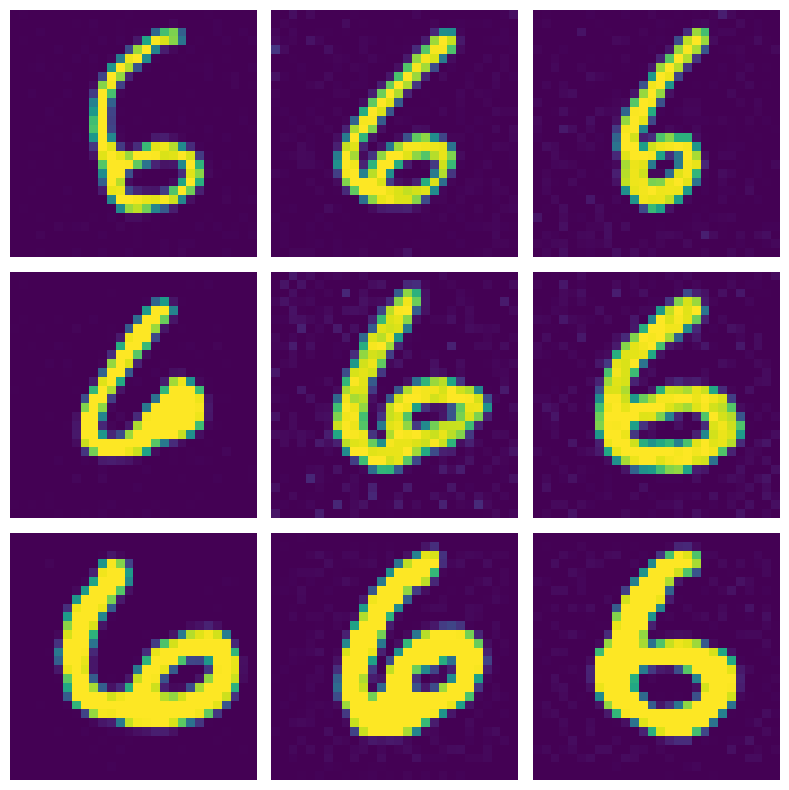

In [47]:
labels = torch.ones(9)*6# Labels 1-9
thickness_values = torch.linspace(2,4,9)  # Different thickness values

samples = generate_samples_with_ema(sampling_model, rf, y=labels, thickness=thickness_values,
                                   cfg_scale=3, num_samples=9, num_steps=60, device='cuda')